# **Classificaton Pipeline**

In [ ]:
# NECESSARY IMPORTS
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import os
from tqdm import tqdm
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, accuracy_score
from tensorflow.keras.applications import EfficientNetB3, EfficientNetB4
from tensorflow.keras.applications.efficientnet import preprocess_input
from tensorflow.keras.optimizers import AdamW
from tensorflow.keras.models import Model, load_model
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization, ReLU, GlobalAveragePooling2D, Input
from tensorflow.keras.preprocessing.image import ImageDataGenerator, load_img, img_to_array
from tensorflow.keras.metrics import TopKCategoricalAccuracy
from tensorflow.keras.losses import CategoricalCrossentropy
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

In [ ]:
# Global Configuration and Hyperparameters
print(" Initializing global configuration and hyperparameters...")

DATA_DIR = '/content/Data/Train'
TEST_DIR = '/content/Data/Pridect'
NUM_CLASSES = 16
BATCH_SIZE = 32
IMG_SIZE = (300, 300)
MODEL_SAVE_PATH = 'best_model.keras'

# Data Transformations and Augmentation
print(" Setting up data transformations and augmentations...\n")

train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=10,
    horizontal_flip=True,
    brightness_range=[0.8, 1.2],
    zoom_range=0.1,
    width_shift_range=0.1,
    height_shift_range=0.1,
    shear_range=0.1,
    validation_split=0.2
)
val_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    validation_split=0.2
)

train_loader = train_datagen.flow_from_directory(
    DATA_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training',
    shuffle=True
)
val_loader = val_datagen.flow_from_directory(
    DATA_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation',
    shuffle=False
)
# Dataset Loading and Preparation
print(" Loading datasets and preparing data loaders...")

class_names = sorted(os.listdir(DATA_DIR))
# Filter out any non-directory files
class_names = [d for d in class_names if os.path.isdir(os.path.join(DATA_DIR, d))]
class_names = sorted(class_names, key=lambda x: int(x))
class_to_idx = {cls_name: i for i, cls_name in enumerate(class_names)}
idx_to_class = {i: cls_name for cls_name, i in class_to_idx.items()}

print(f"\nDetected {len(class_names)} classes: {class_names}.")

print("\n Counting samples per class:")

class_counts = {}
total_samples = 0
for class_name in class_names:
    class_dir = os.path.join(DATA_DIR, class_name)
    count = len([f for f in os.listdir(class_dir) if os.path.isfile(os.path.join(class_dir, f))])
    class_counts[class_name] = count
    total_samples += count

sorted_class_counts = {k: v for k, v in sorted(class_counts.items(), key=lambda item: int(item[0]))}
for class_name, count in sorted_class_counts.items():
    print(f"Class {class_name}: {count} samples")

print(f"\nTotal samples found: {total_samples}")

⚙️ Initializing global configuration and hyperparameters...
 Setting up data transformations and augmentations...

Found 3671 images belonging to 16 classes.
Found 916 images belonging to 16 classes.
 Loading datasets and preparing data loaders...

Detected 16 classes: ['-1', '0', '1', '2', '3', '4', '5', '6', '7', '8', '9', '10', '11', '12', '13', '14'].

 Counting samples per class:
Class -1: 1809 samples
Class 0: 186 samples
Class 1: 185 samples
Class 2: 185 samples
Class 3: 187 samples
Class 4: 185 samples
Class 5: 185 samples
Class 6: 185 samples
Class 7: 185 samples
Class 8: 185 samples
Class 9: 185 samples
Class 10: 185 samples
Class 11: 185 samples
Class 12: 185 samples
Class 13: 185 samples
Class 14: 185 samples

Total samples found: 4587


In [ ]:
# Model Initialization
print(" Initializing EfficientNetB4 model...")

base_model = EfficientNetB4(include_top=False, weights='imagenet', input_shape=(300, 300, 3))
for layer in base_model.layers:
    layer.trainable = True

inputs = Input(shape=(300, 300, 3))  # input shape
x = base_model(inputs, training=True)
x = GlobalAveragePooling2D()(x)
x = Dense(512)(x)
x = ReLU()(x)
x = Dropout(0.4)(x)
x = BatchNormalization()(x)
x = Dense(256)(x)
x = ReLU()(x)
x = Dropout(0.4)(x)
x = BatchNormalization()(x)
outputs = Dense(NUM_CLASSES, activation='softmax')(x)

model = Model(inputs, outputs)
loss_fn = CategoricalCrossentropy(label_smoothing=0.1)
model.compile(
    optimizer=AdamW(learning_rate=1e-4),
    loss=loss_fn,
    metrics=['accuracy', TopKCategoricalAccuracy(k=3, name='top_3_accuracy')]
)
# DEFINING CALLBACKS
print("⚙️ Setting up callbacks...")

callbacks = [
    ReduceLROnPlateau(monitor='val_loss', factor=0.3, patience=3, verbose=1),
    EarlyStopping(patience=5, restore_best_weights=True, monitor='val_loss'),
    ModelCheckpoint(MODEL_SAVE_PATH, save_best_only=True, monitor='val_accuracy', verbose=1)
]
# TRAINING THE MODEL
print(" Training the model...")

EPOCHS = 50

history = model.fit(
    train_loader,
    validation_data=val_loader,
    epochs=EPOCHS,
    callbacks=callbacks,
    verbose=1
)

 Initializing EfficientNetB4 model...
⚙️ Setting up callbacks...
 Training the model...
Epoch 1/50
115/115 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.1000 - loss: 3.3489 - top_3_accuracy: 0.2599
Epoch 1: val_accuracy improved from -inf to 0.35590, saving model to best_model.keras
115/115 ━━━━━━━━━━━━━━━━━━━━ 429s 2s/step - accuracy: 0.1004 - loss: 3.3469 - top_3_accuracy: 0.2605 - val_accuracy: 0.3559 - val_loss: 2.3611 - val_top_3_accuracy: 0.5590 - learning_rate: 1.0000e-04
Epoch 2/50
115/115 ━━━━━━━━━━━━━━━━━━━━ 0s 995ms/step - accuracy: 0.3025 - loss: 2.5592 - top_3_accuracy: 0.5099
Epoch 2: val_accuracy improved from 0.35590 to 0.50983, saving model to best_model.keras
115/115 ━━━━━━━━━━━━━━━━━━━━ 123s 1s/step - accuracy: 0.3028 - loss: 2.5580 - top_3_accuracy: 0.5103 - val_accuracy: 0.5098 - val_loss: 1.9441 - val_top_3_accuracy: 0.7293 - learning_rate: 1.0000e-04
Epoch 3/50
115/115 ━━━━━━━━━━━━━━━━━━━━ 0s 991ms/step - accuracy: 0.4593 - loss: 2.0463 - top_3_accuracy: 0.6841
E

In [ ]:
# Final Evaluation and Classification Report
print(" Performing final evaluation on the validation set...")

# Load the best model saved during training
best_model = load_model(MODEL_SAVE_PATH, custom_objects={'TopKCategoricalAccuracy': TopKCategoricalAccuracy})

# Reset the validation loader to ensure predictions are made on the entire validation set
val_loader.reset()

# Get true labels and predictions for the validation set
y_true_final = val_loader.classes
y_pred_probs = best_model.predict(val_loader)
y_pred_final = np.argmax(y_pred_probs, axis=1)

# Calculate Top-1 accuracy
val_acc = accuracy_score(y_true_final, y_pred_final)

# Calculate Top-3 accuracy
top3_correct = 0
for i in range(len(val_loader)):
    X_batch, y_batch = val_loader[i]
    preds = best_model.predict(X_batch)
    top3 = np.argsort(preds, axis=1)[:, -3:]
    for j in range(len(y_batch)):
        if np.argmax(y_batch[j]) in top3[j]:
            top3_correct += 1

top3_acc = top3_correct / len(y_true_final)

print("\n--- Classification Report ---")
# Ensure target_names match the order of class_indices from the generator
generator_class_indices = val_loader.class_indices
sorted_class_names = [item[0] for item in sorted(generator_class_indices.items(), key=lambda item: item[1])]

report = classification_report(y_true_final, y_pred_final, target_names=sorted_class_names, digits=4)
print(report)


print(f"\nFinal Eval - Top-1 Acc: {val_acc:.4f} | Top-3 Acc: {top3_acc:.4f}")

 Performing final evaluation on the validation set...
29/29 ━━━━━━━━━━━━━━━━━━━━ 31s 626ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 13s 13s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 231ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 205ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 200ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 198ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 220ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 196ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 224ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 199ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 194ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 184ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 197ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 184ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 200ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 172ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 200ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 185ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 198ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 186ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 193ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 184ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 194ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 185ms/step
1/1 ━━━━

# **Testing Phase**

In [ ]:
import json
with open('class_indices.json', 'w') as f:
    json.dump(train_loader.class_indices, f)
# Later, for inference:
with open('class_indices.json') as f:
    class_indices = json.load(f)
idx_to_class = {v: k for k, v in class_indices.items()}

In [ ]:
# Load mapping
idx_to_class = {v: k for k, v in train_loader.class_indices.items()}

In [ ]:
print(idx_to_class)

{0: '-1', 1: '0', 2: '1', 3: '10', 4: '11', 5: '12', 6: '13', 7: '14', 8: '2', 9: '3', 10: '4', 11: '5', 12: '6', 13: '7', 14: '8', 15: '9'}


In [ ]:
best_model = "/content/best_model.keras"

In [ ]:
# Get random images from predict folder
import random
PREDICT_DIR = '/content/Data/Pridect'
predict_images = [f for f in os.listdir(PREDICT_DIR) if f.lower().endswith(('jpg', 'jpeg', 'png'))]
num_to_show = 5  # how many random images to test
random_imgs = random.sample(predict_images, min(num_to_show, len(predict_images)))

1/1 ━━━━━━━━━━━━━━━━━━━━ 12s 12s/step


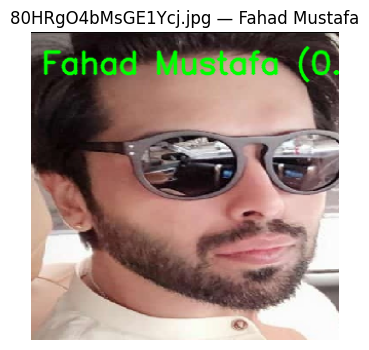

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step


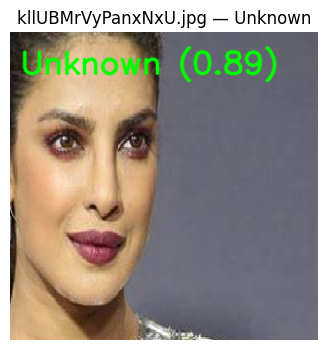

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step


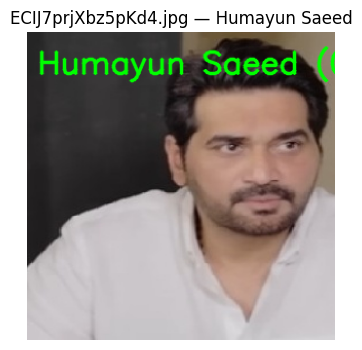

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step


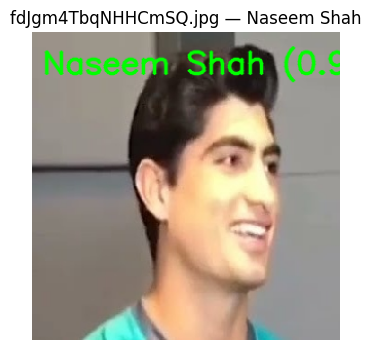

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step


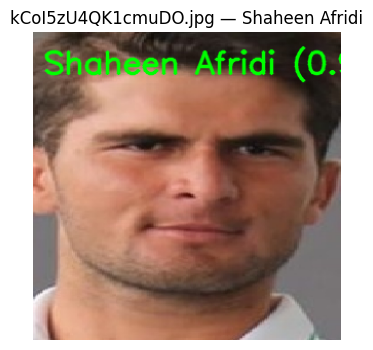

In [ ]:
import cv2

# Load the best model saved during training
best_model = load_model(best_model, custom_objects={'TopKCategoricalAccuracy': TopKCategoricalAccuracy})

label_to_name = {
    '-1': 'Unknown',
    '0': 'Iqra Aziz',
    '1': 'Humayun Saeed',
    '2': 'Kubra Khan',
    '3': 'Mahira Khan',
    '4': 'Naseem Shah',
    '5': 'Nauman Ijaz',
    '6': 'Neelum Munir',
    '7': 'Ramsha Khan',
    '8': 'Sajjal Ali',
    '9': 'Shaheen Afridi',
    '10': 'Atif Aslam',
    '11': 'Fahad Mustafa',
    '12': 'Fawad Khan',
    '13': 'Hamza Ali Abbasi',
    '14': 'Hania Aamir'
}

for fname in random_imgs:
    img_path = os.path.join(PREDICT_DIR, fname)
    # Load and preprocess exactly as in your pipeline
    img = load_img(img_path, target_size=(300, 300))
    x = img_to_array(img)
    x = preprocess_input(x)
    x = np.expand_dims(x, axis=0)

    # Predict
    pred = best_model.predict(x)
    label_idx = np.argmax(pred)
    label = idx_to_class[label_idx]
    display_label = label_to_name.get(label, "Unknown")
    confidence = pred[0][label_idx]

    # Draw label on image (on resized 300x300 image)
    img_draw = np.array(img).astype(np.uint8)
    img_draw = cv2.putText(
        img_draw, f'{display_label} ({confidence:.2f})',
        (10, 40), cv2.FONT_HERSHEY_SIMPLEX, 1, (0,255,0), 2, cv2.LINE_AA
    )

    plt.figure(figsize=(4, 4))
    plt.imshow(img_draw.astype(np.uint8))
    plt.axis('off')
    plt.title(f"{fname} — {display_label}")
    plt.show()

# **Train & Test YOLO Model**

In [ ]:
!pip install ultralytics --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 17.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 73.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 52.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 42.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 6.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 14.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 7.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 5.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 57.8 MB/s eta 0:00:00
Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralyti

In [ ]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
from ultralytics import YOLO
from tensorflow.keras.models import load_model
from tensorflow.keras.utils import load_img, img_to_array
from tensorflow.keras.applications.efficientnet import preprocess_input

from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# YOLOv8n-face gender detection model
yolo_model = YOLO("/content/drive/MyDrive/YoloGenderDetection/runs/yolov8s_gender_finetuned_lr4/weights/best.pt")

# Classification model (EfficientNet)
class_model = load_model("/content/drive/MyDrive/best_model.keras")

# Label mappings
idx_to_class = {
    0: "-1", 1: "0", 2: "1", 3: "10", 4: "11", 5: "12", 6: "13", 7: "14",
    8: "2", 9: "3", 10: "4", 11: "5", 12: "6", 13: "7", 14: "8", 15: "9"
}

label_to_name = {
    "-1": "Unknown", "0": "Iqra", "1": "Humayun", "2": "Kubra",
    "3": "Mahira", "4": "Naseem", "5": "Nauman", "6": "Neelum",
    "7": "Ramsha", "8": "Sajjal", "9": "Shaheen",
    "10": "Atif", "11": "Fahad", "12": "Fawad",
    "13": "Hamza", "14": "Hania"
}

# *Testing Image*


image 1/1 /content/Pakistani-Stars-Kubra-Khan-Mirza-Gohar-Rasheed-Spark-Wedding-Buzz_-Fans-Cant-Keep-Calm.webp: 384x640 1 Female, 398.0ms
Speed: 4.6ms preprocess, 398.0ms inference, 1.3ms postprocess per image at shape (1, 3, 384, 640)


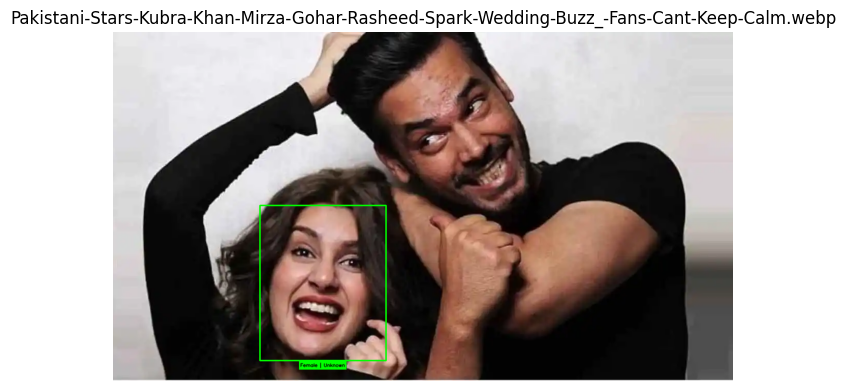

In [ ]:
detect_and_classify("/content/Pakistani-Stars-Kubra-Khan-Mirza-Gohar-Rasheed-Spark-Wedding-Buzz_-Fans-Cant-Keep-Calm.webp")


image 1/1 /content/814a2a2d71ad29e7180c3e8311e6a10a.jpg: 640x640 2 Males, 5 Females, 971.9ms
Speed: 6.5ms preprocess, 971.9ms inference, 1.3ms postprocess per image at shape (1, 3, 640, 640)


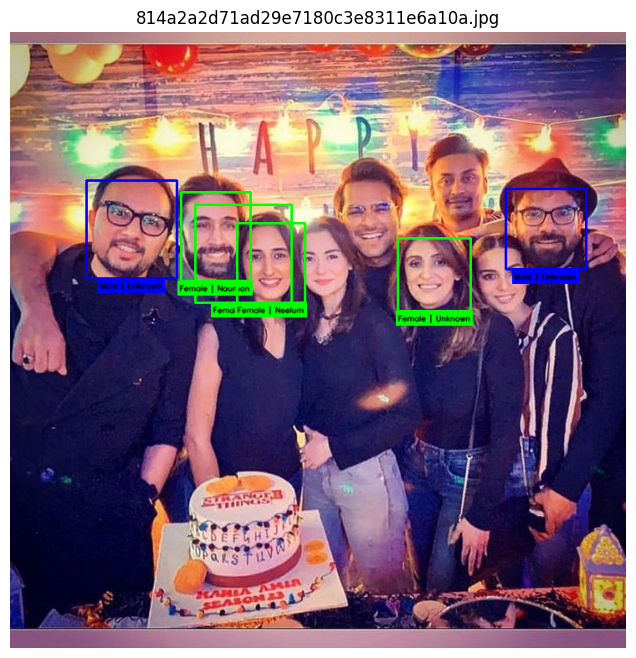

In [ ]:
detect_and_classify("/content/EaoQbgdXkAQ7DG_.jpg")


image 1/1 /content/EaoQbgdXkAQ7DG_.jpg: 640x640 1 Male, 1345.8ms
Speed: 8.3ms preprocess, 1345.8ms inference, 1.8ms postprocess per image at shape (1, 3, 640, 640)


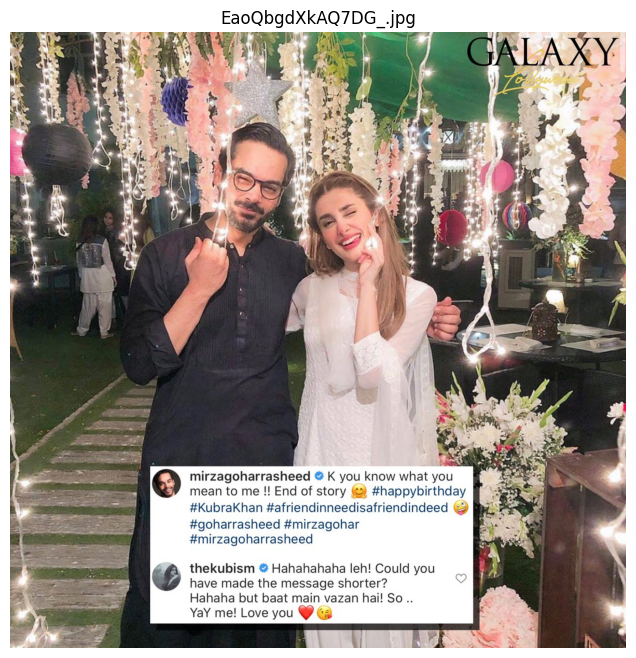

In [ ]:
detect_and_classify("/content/EaoQbgdXkAQ7DG_.jpg")

# **Gender Detection Pipeline**

***Loading The dataset***

In [ ]:
!pip install roboflow --quiet

from roboflow import Roboflow
rf = Roboflow(api_key="pBBKNXR76FHNuWHYgh1f")
project = rf.workspace("seeed-studio-e2fso").project("gender-8vbxd")
version = project.version(1)
dataset = version.download("folder")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 86.8/86.8 kB 3.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 4.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 22.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.2/4.2 MB 69.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 75.6 MB/s eta 0:00:00
loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to gender-1 in folder:: 100%|██████████| 10011/10011 [00:01<00:00, 8322.56it/s]


# **Dataset Analysis**

In [ ]:
import os

base_path = "/content/gender-1"
splits = ['train', 'test', 'valid']
classes = ['Male', 'Female']

print("📊 Dataset Image Distribution:\n")

for split in splits:
    total = 0
    print(f"🔹 {split.upper()}:")
    for cls in classes:
        cls_path = os.path.join(base_path, split, cls)
        count = len([f for f in os.listdir(cls_path) if f.lower().endswith(('.jpg', '.jpeg', '.png'))])
        print(f"   🧑 {cls}: {count} images")
        total += count
    print(f"   📦 Total: {total} images\n")

📊 Dataset Image Distribution:

🔹 TRAIN:
   🧑 Male: 3023 images
   🧑 Female: 3977 images
   📦 Total: 7000 images

🔹 TEST:
   🧑 Male: 423 images
   🧑 Female: 577 images
   📦 Total: 1000 images

🔹 VALID:
   🧑 Male: 865 images
   🧑 Female: 1135 images
   📦 Total: 2000 images



In [ ]:
from collections import defaultdict
from pathlib import Path

# Root of the dataset
dataset_root = "/content/gender-1"

# Store filename stems and where they were found
stem_tracker = defaultdict(list)

# Go through all images in all splits and classes
for split in ["train", "valid", "test"]:
    for gender in ["Male", "Female"]:
        folder = os.path.join(dataset_root, split, gender)
        for file in os.listdir(folder):
            if file.lower().endswith(('.jpg', '.jpeg', '.png')):
                stem = Path(file).stem.lower()  # normalize casing
                full_path = os.path.join(folder, file)
                stem_tracker[stem].append(full_path)

# Find duplicates
duplicates = {stem: paths for stem, paths in stem_tracker.items() if len(paths) > 1}

# Print results
print(f"🔍 Found {len(duplicates)} duplicated filename stems (same name, possibly different extensions):\n")
for stem, files in list(duplicates.items())[:20]:  # Show only first 20
    print(f"🧾 '{stem}' found in:")
    for path in files:
        print(f"   └─ {path}")
    print()

if len(duplicates) == 0:
    print("✅ No duplicate filenames detected by stem.")
else:
    print(f"\n⚠️ Total duplicates found: {len(duplicates)}")

🔍 Found 0 duplicated filename stems (same name, possibly different extensions):

✅ No duplicate filenames detected by stem.


In [ ]:
import os
from google.colab import drive

# Mount your Google Drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# *Creating Folder for Yolo format*

In [ ]:
# Set base YOLO project path
base_dir = "/content/drive/MyDrive/YoloGenderDetection"

# Define paths
images_train = os.path.join(base_dir, "images/train")
images_val   = os.path.join(base_dir, "images/val")
images_test  = os.path.join(base_dir, "images/test")

labels_train = os.path.join(base_dir, "labels/train")
labels_val   = os.path.join(base_dir, "labels/val")
labels_test  = os.path.join(base_dir, "labels/test")

# Create all necessary folders
for path in [images_train, images_val, images_test, labels_train, labels_val, labels_test]:
    os.makedirs(path, exist_ok=True)

print("✅ YOLOv8 folder structure created under:", base_dir)

✅ YOLOv8 folder structure created under: /content/drive/MyDrive/YoloGenderDetection


# *20 random images for manual annotations*

In [ ]:
import shutil
import random
import os

# Source dataset location (your original classification folders)
source_dir = "/content/gender-1"

# Destination folder for annotation images (stored in Google Drive)
annotation_images_dir = images_train

# Get all images from the 'train' split
image_paths = []
# Iterate through the 'train' split
split = 'train'
split_path = os.path.join(source_dir, split)
print(f"Debug: Checking source directory: {source_dir}")
print(f"Debug: Checking split path: {split_path}")
if os.path.isdir(split_path):
    print(f"Debug: Found split directory: {split_path}")
    for cls in os.listdir(split_path):
        cls_path = os.path.join(split_path, cls)
        print(f"Debug: Checking class path: {cls_path}")
        if os.path.isdir(cls_path):
            print(f"Debug: Found class directory: {cls_path}")
            for file in os.listdir(cls_path):
                if file.lower().endswith((".jpg", ".jpeg", ".png")):
                    full_file_path = os.path.join(cls_path, file)
                    image_paths.append(full_file_path)
                    # print(f"Debug: Found image: {full_file_path}") # Uncomment for detailed file listing
        else:
            print(f"Debug: Not a directory, skipping: {cls_path}")
else:
    print(f"Debug: Not a directory, skipping: {split_path}")

print(f"\nDebug: Total images found in '{split}': {len(image_paths)}")

# Select 20 random images
# Add a check to ensure there are enough images
if len(image_paths) >= 20:
    sample_paths = random.sample(image_paths, 20)

    # Ensure the destination directory exists before copying
    os.makedirs(annotation_images_dir, exist_ok=True)
    print(f"Debug: Ensuring destination directory exists: {annotation_images_dir}")

    # Copy to Google Drive for annotation
    for path in sample_paths:
        shutil.copy(path, annotation_images_dir)

    print(f"✅ Copied {len(sample_paths)} images to Google Drive for manual annotation.")
else:
    print(f"⚠️ Not enough images ({len(image_paths)}) found in '{split}' to select 20 for annotation.")

Debug: Checking source directory: /content/gender-1
Debug: Checking split path: /content/gender-1/train
Debug: Found split directory: /content/gender-1/train
Debug: Checking class path: /content/gender-1/train/Female
Debug: Found class directory: /content/gender-1/train/Female
Debug: Checking class path: /content/gender-1/train/Male
Debug: Found class directory: /content/gender-1/train/Male

Debug: Total images found in 'train': 7000
Debug: Ensuring destination directory exists: /content/drive/MyDrive/YoloGenderDetection/images/train
✅ Copied 20 images to Google Drive for manual annotation.


# *Saving names to remove from orignal Train set*


---

# *So we don't duplicate them when auto annotating*

In [ ]:
# Folder where manually annotated images are stored
manual_annotated_dir = "/content/drive/MyDrive/YoloGenderDetection/images/train"

# Store full filenames with extensions
manual_files = set()

print("🔒 Skipping these manually annotated image files:\n")

for f in os.listdir(manual_annotated_dir):
    if f.lower().endswith(('.jpg', '.jpeg', '.png')):
        manual_files.add(f)
        print("🗂️", f)

print(f"\n✅ Total: {len(manual_files)} full filenames stored (with extension).")

🔒 Skipping these manually annotated image files:

🗂️ 175086_jpg.rf.6f35668bca9ef6b298ff027f9310b157.jpg
🗂️ 164126_jpg.rf.d57de1e51d76e2238159c51724ca6e85.jpg
🗂️ 166803_jpg.rf.b84efb321dbc7e27b570d926ad3d85b9.jpg
🗂️ 174942_jpg.rf.d1d7a43c56db1f8b91f0093fa67b8d50.jpg
🗂️ 160416_jpg.rf.f423c17c09f9a46b5844069c57c6d644.jpg
🗂️ 177183_jpg.rf.6f2fb033ab4333b97e9785bb6ece0033.jpg
🗂️ 175244_jpg.rf.17ed94349e97e8788297ee57825233d4.jpg
🗂️ 168290_jpg.rf.41aad97df30abfce52863fa45074ec4e.jpg
🗂️ 174791_jpg.rf.2d599c50f583df6c419d782a94b9f368.jpg
🗂️ 173044_jpg.rf.9b4ff4e98462ebcc476a3506e0025565.jpg
🗂️ 161151_jpg.rf.f9d37fd2852b2a518d28bb5b84aa939c.jpg
🗂️ 163485_jpg.rf.adc119f199770a042c4b99722dc11e62.jpg
🗂️ 160804_jpg.rf.98d97b8466116648dc34cc6ff5a36689.jpg
🗂️ 170553_jpg.rf.bf78405bfca6d8e9e65865ef0a7a5ce8.jpg
🗂️ 168265_jpg.rf.75c66e9154f24c10b9b1d8a0bdc1a521.jpg
🗂️ 168315_jpg.rf.4c425fd7ab10ec0cdae318e01cac5c13.jpg
🗂️ 169274_jpg.rf.0809f0fcd4f613b72c8b95f0ef413331.jpg
🗂️ 177576_jpg.rf.782c3a31185c5e6

# *Removing those from orignal Train set*

In [ ]:
# Folder to search for matches (recursive)
train_root = "/content/gender-1/train"

# Track what we delete
deleted_files = []

# Walk through the dataset and delete exact filename matches
for folder, _, files in os.walk(train_root):
    for file in files:
        if file in manual_files:
            full_path = os.path.join(folder, file)
            os.remove(full_path)
            deleted_files.append(full_path)
            print(f"🗑️ Deleted: {full_path}")

print(f"\n✅ Total deleted from original dataset: {len(deleted_files)} files.")

🗑️ Deleted: /content/gender-1/train/Female/170553_jpg.rf.bf78405bfca6d8e9e65865ef0a7a5ce8.jpg
🗑️ Deleted: /content/gender-1/train/Female/161151_jpg.rf.f9d37fd2852b2a518d28bb5b84aa939c.jpg
🗑️ Deleted: /content/gender-1/train/Female/160416_jpg.rf.f423c17c09f9a46b5844069c57c6d644.jpg
🗑️ Deleted: /content/gender-1/train/Female/168265_jpg.rf.75c66e9154f24c10b9b1d8a0bdc1a521.jpg
🗑️ Deleted: /content/gender-1/train/Female/168315_jpg.rf.4c425fd7ab10ec0cdae318e01cac5c13.jpg
🗑️ Deleted: /content/gender-1/train/Female/175244_jpg.rf.17ed94349e97e8788297ee57825233d4.jpg
🗑️ Deleted: /content/gender-1/train/Female/174791_jpg.rf.2d599c50f583df6c419d782a94b9f368.jpg
🗑️ Deleted: /content/gender-1/train/Female/174942_jpg.rf.d1d7a43c56db1f8b91f0093fa67b8d50.jpg
🗑️ Deleted: /content/gender-1/train/Female/166803_jpg.rf.b84efb321dbc7e27b570d926ad3d85b9.jpg
🗑️ Deleted: /content/gender-1/train/Female/164126_jpg.rf.d57de1e51d76e2238159c51724ca6e85.jpg
🗑️ Deleted: /content/gender-1/train/Female/163485_jpg.rf.adc

# *Auto Annotations Setup*

In [ ]:
!pip install ultralytics --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 17.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 3.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 111.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 89.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 50.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 5.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 13.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 7.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 5.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 95.2 MB/s eta 0:00:00


***Using Pre-trained Yolov11n-face-detction model for auto annotating the images***

Link=https://huggingface.co/AdamCodd/YOLOv11n-face-detection

In [ ]:
from huggingface_hub import hf_hub_download
from ultralytics import YOLO

# Download YOLOv11n face detection model
model_path = hf_hub_download(repo_id="AdamCodd/YOLOv11n-face-detection", filename="model.pt")
model = YOLO(model_path)

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.



The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.


model.pt:   0%|          | 0.00/5.47M [00:00<?, ?B/s]

*Testing performance*


image 1/1 /content/drive/MyDrive/YoloGenderDetection/images/train/160014_jpg.rf.c27227db7d1a1d898f86c4e86b82f899.jpg: 640x544 1 face, 512.4ms
Speed: 23.9ms preprocess, 512.4ms inference, 31.0ms postprocess per image at shape (1, 3, 640, 544)
✅ Saved label: /content/drive/MyDrive/YoloGenderDetection/labels/train/160014_jpg.rf.c27227db7d1a1d898f86c4e86b82f899.txt


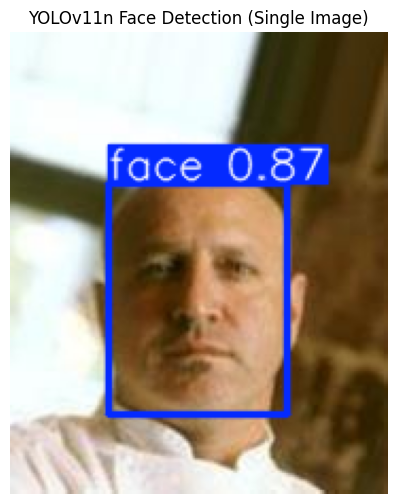

In [ ]:
from pathlib import Path
import shutil
import cv2
import matplotlib.pyplot as plt

# --- Paths ---
base_dir = "/content/drive/MyDrive/YoloGenderDetection"
src_img = "/content/gender-1/train/Male/160014_jpg.rf.c27227db7d1a1d898f86c4e86b82f899.jpg"
dst_img = os.path.join(base_dir, "images/train", os.path.basename(src_img))
dst_label = os.path.join(base_dir, "labels/train", Path(src_img).stem + ".txt")

# --- Gender class based on folder ---
gender_class = 0  # 0 = Male

# --- Copy image ---
shutil.copy2(src_img, dst_img)

# --- Run inference ---
results = model(dst_img)
boxes = results[0].boxes
image = cv2.imread(dst_img)
h, w = image.shape[:2]

# --- Process and Save annotation ---
with open(dst_label, "w") as f:
    for box in boxes.xywhn:  # Normalized center_x, center_y, w, h
        cx, cy, bw, bh = box.tolist()
        f.write(f"{gender_class} {cx:.6f} {cy:.6f} {bw:.6f} {bh:.6f}\n")

print(f"✅ Saved label: {dst_label}")

# --- Visualize detection ---
annotated = results[0].plot()
plt.figure(figsize=(6, 6))
plt.imshow(cv2.cvtColor(annotated, cv2.COLOR_BGR2RGB))
plt.axis('off')
plt.title("YOLOv11n Face Detection (Single Image)")
plt.show()

***Auto Annotations on Train & Val***

*   *Detect-->Faces+Labels-->Copy to drive*




In [ ]:
# Directories
source_root = "/content/gender-1"  # Original Roboflow folder
target_root = "/content/drive/MyDrive/YoloGenderDetection"

splits = ["train", "valid"]
gender_map = {"Male": 0, "Female": 1}
filename_to_class = {}

# Loop through train/valid + male/female
for split in splits:
    for gender in ["Male", "Female"]:
        src_dir = os.path.join(source_root, split, gender)
        dst_img_dir = os.path.join(target_root, f"images/{split}")
        dst_lbl_dir = os.path.join(target_root, f"labels/{split}")
        os.makedirs(dst_img_dir, exist_ok=True)
        os.makedirs(dst_lbl_dir, exist_ok=True)

        for fname in sorted(os.listdir(src_dir)):
            if not fname.lower().endswith((".jpg", ".jpeg", ".png")):
                continue

            src_path = os.path.join(src_dir, fname)
            dst_img_path = os.path.join(dst_img_dir, fname)
            dst_lbl_path = os.path.join(dst_lbl_dir, Path(fname).stem + ".txt")

            # Skip if label already exists (manual or previous)
            if os.path.exists(dst_lbl_path):
                print(f"⏭️ Skipping (label exists): {fname}")
                continue

            # Run face detection
            try:
                results = model(src_path)
                boxes = results[0].boxes.xywhn  # normalized cx, cy, w, h

                if boxes is not None and len(boxes) > 0:
                    # Save label
                    with open(dst_lbl_path, "w") as f:
                        for box in boxes:
                            cx, cy, bw, bh = box.tolist()
                            f.write(f"{gender_map[gender]} {cx:.6f} {cy:.6f} {bw:.6f} {bh:.6f}\n")

                    # Save image (copy)
                    shutil.copy2(src_path, dst_img_path)
                    filename_to_class[fname] = gender_map[gender]
                    print(f"✅ Annotated + Copied: {fname} → class {gender_map[gender]}")
                else:
                    print(f"⚠️ No face detected: {fname}")

            except Exception as e:
                print(f"❌ Error with {fname}: {e}")

# Save class map (optional but useful)
map_path = os.path.join(target_root, "filename_to_class.txt")
with open(map_path, "w") as f:
    for fname, cls in filename_to_class.items():
        f.write(f"{fname},{cls}\n")

print("\n✅ DONE: All images annotated and copied with original names.")
print(f"📦 Total saved: {len(filename_to_class)} images")
print(f"📝 Mapping saved to: {map_path}")

Streaming output truncated to the last 5000 lines.

image 1/1 /content/gender-1/valid/Male/177123_jpg.rf.d39a139a380fa2a96a197d0a3e0d2ead.jpg: 640x544 1 face, 190.5ms
Speed: 6.1ms preprocess, 190.5ms inference, 1.3ms postprocess per image at shape (1, 3, 640, 544)
✅ Annotated + Copied: 177123_jpg.rf.d39a139a380fa2a96a197d0a3e0d2ead.jpg → class 0

image 1/1 /content/gender-1/valid/Male/177127_jpg.rf.f238105539398c422238d2cb57eb1689.jpg: 640x544 1 face, 208.0ms
Speed: 4.5ms preprocess, 208.0ms inference, 1.2ms postprocess per image at shape (1, 3, 640, 544)
✅ Annotated + Copied: 177127_jpg.rf.f238105539398c422238d2cb57eb1689.jpg → class 0

image 1/1 /content/gender-1/valid/Male/177160_jpg.rf.b328b75579db61a7f6f98e93e1358567.jpg: 640x544 1 face, 212.9ms
Speed: 6.7ms preprocess, 212.9ms inference, 1.1ms postprocess per image at shape (1, 3, 640, 544)
✅ Annotated + Copied: 177160_jpg.rf.b328b75579db61a7f6f98e93e1358567.jpg → class 0

image 1/1 /content/gender-1/valid/Male/177206_jpg.rf.b272

**Verification**

In [ ]:
img_dir_train = "/content/drive/MyDrive/YoloGenderDetection/images/train"
lbl_dir_train = "/content/drive/MyDrive/YoloGenderDetection/labels/train"

img_dir_valid = "/content/drive/MyDrive/YoloGenderDetection/images/valid"
lbl_dir_valid = "/content/drive/MyDrive/YoloGenderDetection/labels/valid"


# Count image files in train
img_count_train = len([f for f in os.listdir(img_dir_train) if f.lower().endswith(('.jpg', '.jpeg', '.png'))])

# Count label files in train
lbl_count_train = len([f for f in os.listdir(lbl_dir_train) if f.lower().endswith('.txt')])

print(f"🖼️ Total training images: {img_count_train}")
print(f"📝 Total training label files:     {lbl_count_train}")

# Sanity check for train
if img_count_train != lbl_count_train:
    print("⚠️ Mismatch in training set: Some images may not have labels or vice versa.")
else:
    print("✅ All training images have corresponding labels.")

print("-" * 30) # Separator

# Count image files in valid
img_count_valid = len([f for f in os.listdir(img_dir_valid) if f.lower().endswith(('.jpg', '.jpeg', '.png'))])

# Count label files in valid
lbl_count_valid = len([f for f in os.listdir(lbl_dir_valid) if f.lower().endswith('.txt')])

print(f"🖼️ Total validation images: {img_count_valid}")
print(f"📝 Total validation label files:     {lbl_count_valid}")

# Sanity check for valid
if img_count_valid != lbl_count_valid:
    print("⚠️ Mismatch in validation set: Some images may not have labels or vice versa.")
else:
    print("✅ All validation images have corresponding labels.")

🖼️ Total training images: 6997
📝 Total training label files:     6997
✅ All training images have corresponding labels.
------------------------------
🖼️ Total validation images: 1994
📝 Total validation label files:     1994
✅ All validation images have corresponding labels.


*Copying Test Images as it is. No labels, obviously ;)

In [ ]:
src_root = "/content/gender-1/test"
dst_root = "/content/drive/MyDrive/YoloGenderDetection/images/test"
os.makedirs(dst_root, exist_ok=True)

total_copied = 0

for gender in ["Male", "Female"]:
    src_dir = os.path.join(src_root, gender)
    for fname in os.listdir(src_dir):
        if fname.lower().endswith(('.jpg', '.jpeg', '.png')):
            src_file = os.path.join(src_dir, fname)
            dst_file = os.path.join(dst_root, fname)
            shutil.copy2(src_file, dst_file)
            total_copied += 1

print(f"✅ Copied {total_copied} test images to: {dst_root}")

✅ Copied 1000 test images to: /content/drive/MyDrive/YoloGenderDetection/images/test


**".yaml" File Setup**

In [ ]:
yaml_path = "/content/drive/MyDrive/YoloGenderDetection/data.yaml"

with open(yaml_path, "w") as f:
    f.write("""path: /content/drive/MyDrive/YoloGenderDetection
train: images/train
val: images/valid

names:
  0: Male
  1: Female
""")

print(f"✅ YOLO config saved to: {yaml_path}")

✅ YOLO config saved to: /content/drive/MyDrive/YoloGenderDetection/data.yaml


In [ ]:
yaml_path = "/content/drive/MyDrive/YoloGenderDetection/data.yaml"

try:
    with open(yaml_path, "r") as f:
        print(f.read())
except FileNotFoundError:
    print(f"Error: The file {yaml_path} was not found.")
except Exception as e:
    print(f"An error occurred while reading the file: {e}")

path: /content/drive/MyDrive/YoloGenderDetection
train: images/train
val: images/valid

names:
  0: Male
  1: Female



# **Training our Model for Gender Detection**

In [ ]:
from ultralytics import YOLO

model = YOLO("yolov8s.pt")  # 🔁 Load pre-trained YOLOv8s

model.train(
    data="/content/drive/MyDrive/YoloGenderDetection/data.yaml",
    epochs=50,
    imgsz=640,
    batch=16,
    save=True,
    name="yolov8s_gender2",
    project="/content/drive/MyDrive/YoloGenderDetection/runs"
)

Ultralytics 8.3.162 🚀 Python-3.11.13 torch-2.6.0+cu124 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/drive/MyDrive/YoloGenderDetection/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8s.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=yolov8s_gender2, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100, perspective=0.0,

100%|██████████| 755k/755k [00:00<00:00, 15.3MB/s]

Overriding model.yaml nc=80 with nc=2

                   from  n    params  module                                       arguments                     
  0                  -1  1       928  ultralytics.nn.modules.conv.Conv             [3, 32, 3, 2]                 
  1                  -1  1     18560  ultralytics.nn.modules.conv.Conv             [32, 64, 3, 2]                
  2                  -1  1     29056  ultralytics.nn.modules.block.C2f             [64, 64, 1, True]             
  3                  -1  1     73984  ultralytics.nn.modules.conv.Conv             [64, 128, 3, 2]               
  4                  -1  2    197632  ultralytics.nn.modules.block.C2f             [128, 128, 2, True]           
  5                  -1  1    295424  ultralytics.nn.modules.conv.Conv             [128, 256, 3, 2]              
  6                  -1  2    788480  ultralytics.nn.modules.block.C2f             [256, 256, 2, True]           
  7                  -1  1   1180672  ultralytics

 18                  -1  1    493056  ultralytics.nn.modules.block.C2f             [384, 256, 1]                 
 19                  -1  1    590336  ultralytics.nn.modules.conv.Conv             [256, 256, 3, 2]              
 20             [-1, 9]  1         0  ultralytics.nn.modules.conv.Concat           [1]                           
 21                  -1  1   1969152  ultralytics.nn.modules.block.C2f             [768, 512, 1]                 
 22        [15, 18, 21]  1   2116822  ultralytics.nn.modules.head.Detect           [2, [128, 256, 512]]          
Model summary: 129 layers, 11,136,374 parameters, 11,136,358 gradients, 28.6 GFLOPs

Transferred 349/355 items from pretrained weights
Freezing layer 'model.22.dfl.conv.weight'
AMP: running Automatic Mixed Precision (AMP) checks...


100%|██████████| 5.35M/5.35M [00:00<00:00, 69.2MB/s]


...

      12/50      4.54G     0.3909     0.3498     0.9343         15        640: 100%|██████████| 438/438 [02:34<00:00,  2.83it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 63/63 [00:19<00:00,  3.27it/s]

                   all       1994       2022      0.969      0.967       0.99      0.961



      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size


      13/50      4.57G      0.373     0.3439     0.9128         36        640:   4%|▍         | 17/438 [00:06<02:51,  2.45it/s]


KeyboardInterrupt: 

***Performance***

In [ ]:
import pandas as pd

csv_path = "/content/drive/MyDrive/YoloGenderDetection/runs/yolov8s_gender2/results.csv"
df = pd.read_csv(csv_path)

# Select and format the desired columns for better readability
metrics_df = df[["epoch", "metrics/precision(B)", "metrics/recall(B)", "metrics/mAP50(B)", "metrics/mAP50-95(B)"]].tail()

print("📊 Final Epoch Metrics:")
# Format the metrics to 4 decimal places
print(metrics_df.to_string(index=False, formatters={
    "metrics/precision(B)": '{:.4f}'.format,
    "metrics/recall(B)": '{:.4f}'.format,
    "metrics/mAP50(B)": '{:.4f}'.format,
    "metrics/mAP50-95(B)": '{:.4f}'.format
}))

📊 Final Epoch Metrics:
 epoch metrics/precision(B) metrics/recall(B) metrics/mAP50(B) metrics/mAP50-95(B)
     8               0.9685            0.9504           0.9884              0.9414
     9               0.9669            0.9704           0.9898              0.9615
    10               0.9752            0.9573           0.9911              0.9634
    11               0.9688            0.9713           0.9903              0.9564
    12               0.9688            0.9666           0.9897              0.9612


# **Testing on Test Set**

In [ ]:
# Load your trained model
model = YOLO("/content/drive/MyDrive/YoloGenderDetection/runs/yolov8s_gender2/weights/best.pt")

# Run prediction on test images
results = model.predict(
    source="/content/drive/MyDrive/YoloGenderDetection/images/test",
    save=True,                # save images with bounding boxes
    conf=0.5,                 # minimum confidence threshold
    project="/content/drive/MyDrive/YoloGenderDetection/runs",
    name="predict_test",     # folder name for output
    imgsz=640
)


image 1/1000 /content/drive/MyDrive/YoloGenderDetection/images/test/160022_jpg.rf.f30b92396142584a157e67acb88fe379.jpg: 640x544 1 Female, 43.9ms
image 2/1000 /content/drive/MyDrive/YoloGenderDetection/images/test/160078_jpg.rf.2919b95c857273cae07b0c0326308431.jpg: 640x544 1 Male, 15.9ms
image 3/1000 /content/drive/MyDrive/YoloGenderDetection/images/test/160081_jpg.rf.34c5f6339fab89148f1fa8d8eec5e1b1.jpg: 640x544 1 Male, 16.2ms
image 4/1000 /content/drive/MyDrive/YoloGenderDetection/images/test/160083_jpg.rf.e67e6efca86d1328d724aa86c2a20321.jpg: 640x544 1 Female, 16.0ms
image 5/1000 /content/drive/MyDrive/YoloGenderDetection/images/test/160091_jpg.rf.443048423730a62820001d5637521715.jpg: 640x544 1 Female, 16.0ms
image 6/1000 /content/drive/MyDrive/YoloGenderDetection/images/test/160200_jpg.rf.29e23f35e56499994078af5ec3205862.jpg: 640x544 1 Female, 16.0ms
image 7/1000 /content/drive/MyDrive/YoloGenderDetection/images/test/160216_jpg.rf.35ec7cdb389d2ca2a9f7368f00b16940.jpg: 640x544 1 Fem

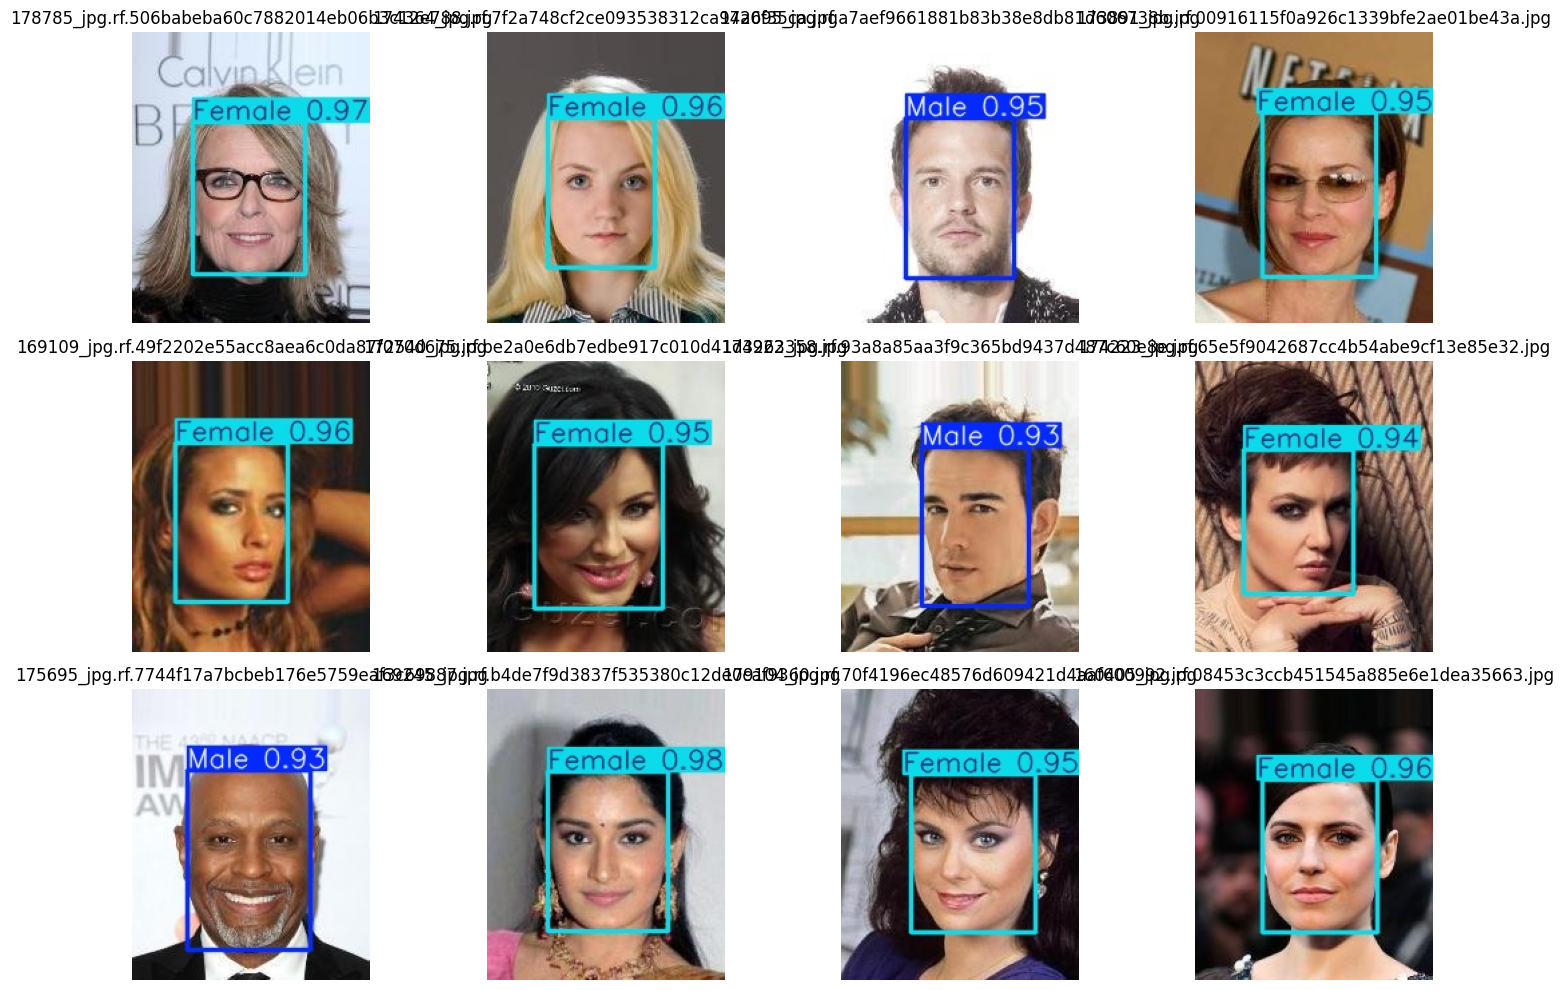

In [ ]:
import matplotlib.pyplot as plt
import cv2
import os
import random

# Path to predicted images
pred_dir = "/content/drive/MyDrive/YoloGenderDetection/runs/predict_test"

# Get all image files in the directory
all_img_files = [os.path.join(pred_dir, f) for f in os.listdir(pred_dir)
             if f.lower().endswith(('.jpg', '.png'))]

# Randomly select up to 12 images
num_images_to_display = min(12, len(all_img_files))
img_files_to_display = random.sample(all_img_files, num_images_to_display)


# Display them
plt.figure(figsize=(15, 10))
for i, img_path in enumerate(img_files_to_display):
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    plt.subplot(3, 4, i+1) # Changed to 3 rows and 4 columns
    plt.imshow(img)
    plt.title(os.path.basename(img_path))
    plt.axis("off")

plt.tight_layout()
plt.show()

# **Pretty Accurate!**